In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#load the clean dataset we saved
df = pd.read_csv('../data/churn_cleaned.csv')

#set a clean visual style for all charts
sns.set_style("whitegrid")

print("Data loaded successfully")
print("Shape:", df.shape)
print("Churn column type:", df['Churn'].dtype)

Data loaded successfully
Shape: (7043, 20)
Churn column type: int64


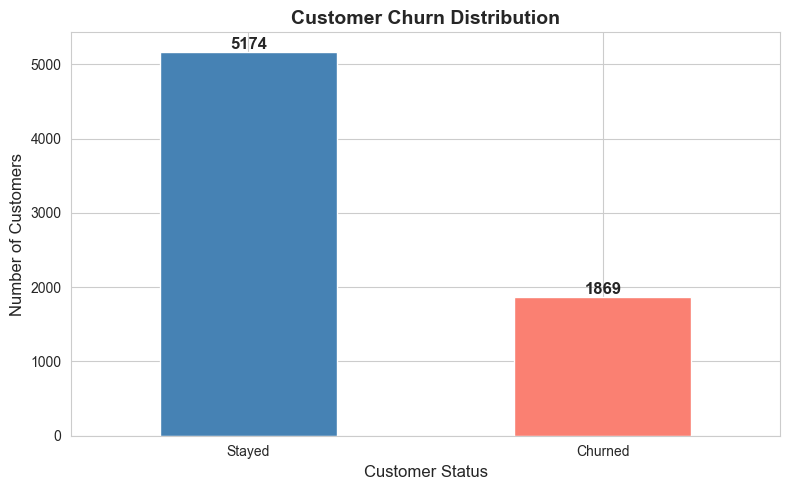

Chart 1 saved


In [3]:
# ============================================
# CHART 1: Churn Distribution
# How many customers stayed vs churned?
# ============================================

fig, ax = plt.subplots(figsize=(8, 5))

df['Churn'].value_counts().plot(
    kind='bar',
    color=['steelblue', 'salmon'],
    ax=ax
)

ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Customer Status', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_xticklabels(['Stayed', 'Churned'], rotation=0)

# Add the actual numbers on top of each bar
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('../reports/churn_distribution.png', dpi=150)
plt.show()

print("Chart 1 saved")

In [4]:
observation_1 = """
CHART 1 FINDING: Customer Churn Distribution
=============================================
- Total customers: 7,043
- Customers retained: 5,174 (73.5%)
- Customers churned: 1,869 (26.5%)

BUSINESS INSIGHT:
Over 1 in 4 customers is leaving this telecom company.
At 26.5%, the churn rate is nearly double the industry 
average of 10-15%. This represents a significant revenue 
risk that justifies investment in a predictive model.
"""
print(observation_1)


CHART 1 FINDING: Customer Churn Distribution
- Total customers: 7,043
- Customers retained: 5,174 (73.5%)
- Customers churned: 1,869 (26.5%)

BUSINESS INSIGHT:
Over 1 in 4 customers is leaving this telecom company.
At 26.5%, the churn rate is nearly double the industry 
average of 10-15%. This represents a significant revenue 
risk that justifies investment in a predictive model.



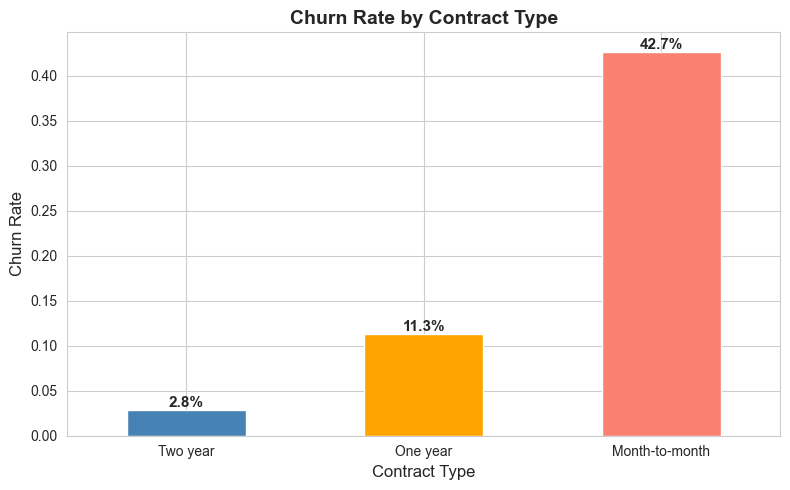

Chart 2 saved


In [5]:
# ============================================
# CHART 2: Churn Rate by Contract Type
# Which contract type loses the most customers?
# ============================================

# Calculate churn rate for each contract type
churn_by_contract = df.groupby('Contract')['Churn'].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))

bars = churn_by_contract.plot(
    kind='bar',
    color=['steelblue', 'orange', 'salmon'],
    ax=ax
)

ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type', fontsize=12)
ax.set_ylabel('Churn Rate', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Add percentage labels on top of each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1%}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('../reports/churn_by_contract.png', dpi=150)
plt.show()

print("Chart 2 saved")

In [6]:
observation_2 = """
CHART 2 FINDING: Churn Rate by Contract Type
=============================================
- Month-to-month contracts: 42.7% churn rate
- One-year contracts: significantly lower
- Two-year contracts: lowest churn rate

BUSINESS INSIGHT:
Contract type is the single strongest predictor of churn
identified so far. Month-to-month customers churn at 42.7%
— meaning almost 1 in 2 leave. Customers on longer contracts
show dramatically better retention.

RECOMMENDATION:
The business should prioritise converting month-to-month 
customers to longer contracts through incentives, discounts,
or loyalty programmes. This single action could have the 
biggest impact on reducing overall churn.
"""
print(observation_2)


CHART 2 FINDING: Churn Rate by Contract Type
- Month-to-month contracts: 42.7% churn rate
- One-year contracts: significantly lower
- Two-year contracts: lowest churn rate

BUSINESS INSIGHT:
Contract type is the single strongest predictor of churn
identified so far. Month-to-month customers churn at 42.7%
— meaning almost 1 in 2 leave. Customers on longer contracts
show dramatically better retention.

RECOMMENDATION:
The business should prioritise converting month-to-month 
customers to longer contracts through incentives, discounts,
or loyalty programmes. This single action could have the 
biggest impact on reducing overall churn.



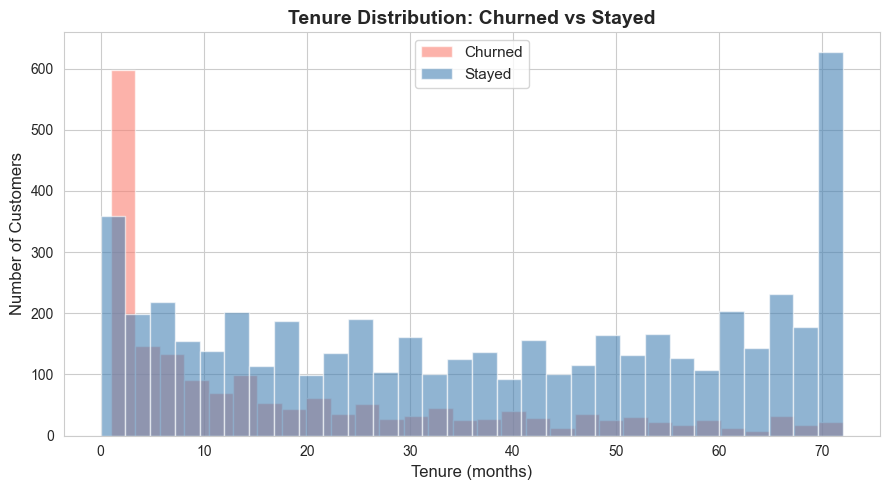

Chart 3 saved


In [7]:
# ============================================
# CHART 3: Tenure Distribution — Churned vs Stayed
# Do newer customers churn more than loyal ones?
# ============================================

fig, ax = plt.subplots(figsize=(9, 5))

# Plot two overlapping histograms
df[df['Churn'] == 1]['tenure'].plot(
    kind='hist',
    bins=30,
    alpha=0.6,
    color='salmon',
    label='Churned',
    ax=ax
)

df[df['Churn'] == 0]['tenure'].plot(
    kind='hist',
    bins=30,
    alpha=0.6,
    color='steelblue',
    label='Stayed',
    ax=ax
)

ax.set_title('Tenure Distribution: Churned vs Stayed',
    fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (months)', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../reports/tenure_vs_churn.png', dpi=150)
plt.show()

print("Chart 3 saved")

In [8]:
observation_3 = """
CHART 3 FINDING: Tenure Distribution — Churned vs Stayed
=========================================================
- Churned customers are heavily concentrated in months 1-12
- Peak churn occurs in the first few months of tenure
- Customers who survive beyond 24 months rarely churn
- Retained customers are spread evenly across all tenure lengths

BUSINESS INSIGHT:
The first 12 months is the critical danger window for 
customer churn. Approximately 600 customers churned 
within their first few months the highest concentration 
in the entire dataset.

RECOMMENDATION:
The business should implement a dedicated onboarding and 
early retention programme specifically targeting new 
customers in months 1 through 12. Early intervention 
 discounts, check-in calls, loyalty rewards could 
significantly reduce this early churn spike.
"""
print(observation_3)


CHART 3 FINDING: Tenure Distribution — Churned vs Stayed
- Churned customers are heavily concentrated in months 1-12
- Peak churn occurs in the first few months of tenure
- Customers who survive beyond 24 months rarely churn
- Retained customers are spread evenly across all tenure lengths

BUSINESS INSIGHT:
The first 12 months is the critical danger window for 
customer churn. Approximately 600 customers churned 
within their first few months the highest concentration 
in the entire dataset.

RECOMMENDATION:
The business should implement a dedicated onboarding and 
early retention programme specifically targeting new 
customers in months 1 through 12. Early intervention 
 discounts, check-in calls, loyalty rewards could 
significantly reduce this early churn spike.



In [9]:
summary = """
DAY 4 SUMMARY — Three Key Findings from Visualisation
======================================================

FINDING 1: High overall churn rate
- 26.5% of customers are churning
- Nearly double the industry average of 10-15%

FINDING 2: Contract type drives churn
- Month-to-month customers churn at 42.7%
- Almost 1 in 2 month-to-month customers leaves
- Longer contracts = dramatically better retention

FINDING 3: Early tenure is the danger window  
- Churn is highest in months 1-12
- ~600 customers churned in first few months
- Customers who stay 24+ months rarely leave

COMBINED INSIGHT:
The highest risk customer profile is:
- On a month-to-month contract AND
- In their first 12 months of tenure

"""
print(summary)


DAY 4 SUMMARY — Three Key Findings from Visualisation

FINDING 1: High overall churn rate
- 26.5% of customers are churning
- Nearly double the industry average of 10-15%

FINDING 2: Contract type drives churn
- Month-to-month customers churn at 42.7%
- Almost 1 in 2 month-to-month customers leaves
- Longer contracts = dramatically better retention

FINDING 3: Early tenure is the danger window  
- Churn is highest in months 1-12
- ~600 customers churned in first few months
- Customers who stay 24+ months rarely leave

COMBINED INSIGHT:
The highest risk customer profile is:
- On a month-to-month contract AND
- In their first 12 months of tenure


